In [15]:
!pip install -q segmentation-models-pytorch
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn.functional as F
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import segmentation_models_pytorch as smp

# Dataset Download
import kagglehub

_ = kagglehub.dataset_download("julinmaloof/the-oxfordiiit-pet-dataset")

IMAGE_DIR = os.path.join(_, "images")
MASK_DIR = os.path.join(_, "annotations", "trimaps")

print(IMAGE_DIR)
print(MASK_DIR)

/kaggle/input/datasets/julinmaloof/the-oxfordiiit-pet-dataset/images
/kaggle/input/datasets/julinmaloof/the-oxfordiiit-pet-dataset/annotations/trimaps


In [11]:
# Ensuring reproducibility
SEED = 10

def seed_everything(seed: int = 10):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device: ', DEVICE)

Using device:  cuda


In [12]:
# Base class for storing the dataset
class OxfordPetDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transforms=False, file_list=None, augment=1):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transforms = transforms
        self.augment = augment
        
        if file_list is not None: 
            self.image_filenames = file_list

        else:
            self.image_filenames = sorted([f for f in os.listdir(images_dir) if f.endswith('jpg')])

    def __len__(self):
        return len(self.image_filenames) * self.augment

    def _load_mask(self, mask_path):
        mask = np.array(Image.open(mask_path))
        binary_mask = np.where(mask == 2, 0, 1).astype(np.float32)
        return binary_mask

    def __getitem__(self, idx):
        if self.augment != 1:
            idx = idx % len(self.image_filenames)
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, img_name.replace('.jpg', '.png'))

        image = Image.open(img_path).convert('RGB')
        mask = self._load_mask(mask_path)

        if self.transforms:
            augmented = self.transforms(image=np.array(image), mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        if not torch.is_tensor(mask):
            mask = torch.from_numpy(mask)

        mask = (mask > 0.5).float()

        return image, mask.unsqueeze(0)

In [13]:
# Function for visualizing a sample given the dataset and index
def visualize_sample(dataset, idx):
    image, mask = dataset[idx]

    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()
    else:
        image = np.array(image)

    if isinstance(mask, torch.Tensor):
        mask = mask.squeeze().cpu().numpy()
    else:
        mask = np.squeeze(mask)

    fig, axes  = plt.subplots(1, 3, figsize = (15, 5))
    axes[0].imshow(image)
    axes[0].set_title('Image')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap = 'gray')
    axes[1].set_title('Mask')
    axes[1].axis('off')

    axes[2].imshow(image)
    axes[2].imshow(mask, alpha = 0.5, cmap = 'jet')
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# 1. Exploratory Data Analysis on the Dataset

## 1.0 Initial Dataset for EDA

In [14]:
dataset_eda = OxfordPetDataset(
    images_dir=IMAGE_DIR,
    masks_dir=MASK_DIR,
    transforms=None)

In [ ]:
# Function for computing the coverage ratio of the foreground
def compute_mask_coverage(dataset):
    coverages = []
    for _, mask in tqdm.tqdm(dataset):
        fg_pixels = mask.sum()
        total_pixels = mask.numel()
        coverages.append((fg_pixels/total_pixels).item())

    return np.array(coverages)

coverages = compute_mask_coverage(dataset_eda)

plt.figure(figsize = (8, 4))
plt.hist(coverages, bins = 30, color = 'royalblue')
plt.title('Foreground Pixel Ratio Distribution')
plt.xlabel("Foreground ratio")
plt.ylabel("Number of images")
plt.show()

print(f'Mean foreground ratio: {coverages.mean():.3f}')
print(f'Min foreground ratio: {coverages.min():.3f}')
print(f'Max foreground ratio: {coverages.max():.3f}')

 17%|█▋        | 1231/7390 [00:54<03:46, 27.15it/s]

In [ ]:
# Visualising the distribution of the resolutions of the images in the dataset
widths, heights = [], []

for img,_ in tqdm.tqdm(dataset_eda):
    w, h = img.size
    widths.append(w)
    heights.append(h)

print(f'Mean Image Width: {sum(widths)/len(widths)}')
print(f'Mean Image Height: {sum(heights)/len(heights)}')

print(f'Most Frequent Image Width: {max(set(widths), key=widths.count)}')
print(f'Most Frequent Image Height: {max(set(heights), key=heights.count)}')

plt.figure(figsize = (10, 4))

plt.subplot(1,2,1)
plt.hist(widths, bins = 30, color = 'orange')
plt.title('Image Width Distribution')

plt.subplot(1, 2, 2)
plt.hist(heights, bins = 30, color = 'purple')
plt.title("Image Height Distribution")

plt.tight_layout()
plt.show()

In [ ]:
for idx in np.random.choice(range(5000), 5, replace = False):
    visualize_sample(dataset_eda, idx)

In [ ]:
# Visualizing samples with very low coverages
min_coverages = np.argsort(coverages)[:5]

for idx in min_coverages:
    visualize_sample(dataset_eda, idx)

In [ ]:
# Visualizing samples with very high coverages
max_coverages = np.argsort(coverages)[-5:]

for idx in max_coverages:
    visualize_sample(dataset_eda, idx)

## 1.1 Data Cleaning

### Samples with very high or very low coverage do not contribute effectively to training our UNet. Therefore, we will be putting a cap to the coverage ratios of the samples; Samples with coverage ratios <10% or >90% shall be removed

In [ ]:
required_indices = np.where((coverages > 0.1) & (coverages < 0.9))[0]

clean_files = [dataset_eda.image_filenames[i] for i in required_indices]

print(f'Original samples: {len(dataset_eda)}')
print(f'Clean samples: {len(clean_files)}')

In [ ]:
cleaned_dataset = OxfordPetDataset(
    images_dir = IMAGE_DIR,
    masks_dir = MASK_DIR,
    transforms = None,
    file_list = clean_files
)

len(cleaned_dataset)

In [ ]:
cleaned_coverages = compute_mask_coverage(cleaned_dataset)

plt.figure(figsize = (8, 4))
plt.hist(cleaned_coverages, bins = 30, color = 'royalblue')
plt.title('Foreground Pixel Ratio Distribution')
plt.xlabel("Foreground ratio")
plt.ylabel("Number of images")
plt.show()

print(f'Mean foreground ratio: {cleaned_coverages.mean():.3f}')
print(f'Min foreground ratio: {cleaned_coverages.min():.3f}')
print(f'Max foreground ratio: {cleaned_coverages.max():.3f}')

In [ ]:
min_coverages_cleaned = np.argsort(cleaned_coverages)[:5]

for idx in min_coverages_cleaned:
    visualize_sample(cleaned_dataset, idx)

In [ ]:
max_coverages_cleaned = np.argsort(cleaned_coverages)[-5:]

for idx in max_coverages_cleaned:
    visualize_sample(cleaned_dataset, idx)

## 1.2 Train-Val Split on the cleaned dataset

In [ ]:
train_files, val_files = train_test_split(
    clean_files,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print(f'Train Samples: {len(train_files)}')
print(f'Validation Samples: {len(val_files)}')

## 1.3 Transforms on Images of the Dataset

### Our goal is to accomplish the following: 
### - Resize all images to a size of 496x496 (closest to 500x500)
### - Add random horizontal flipping to training images
### - Apply ImageNet normalization to all images
### - Convert all images to tensors

In [ ]:
train_transforms = A.Compose([
    A.Resize(496, 496),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
    shift_limit=0.1,
    scale_limit=0.15,
    rotate_limit=20,
    p=0.5),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=15,
        val_shift_limit=10,
        p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(496, 496),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

## 1.4 Final Dataset Construction with Augmentation
### Constructing the final dataset which is both cleaned, split, transformed and augmented appropriately

In [ ]:
train_dataset = OxfordPetDataset(
    images_dir = IMAGE_DIR,
    masks_dir = MASK_DIR,
    transforms = train_transforms,
    file_list = train_files,
    augment = 2
)

val_dataset = OxfordPetDataset(
    images_dir = IMAGE_DIR,
    masks_dir = MASK_DIR,
    transforms = val_transforms,
    file_list = val_files
)

In [ ]:
print(f'Augmented Dataset Samples: {len(train_dataset)}')
print(f'Initial Dataset Samples: {len(train_files)}')

# 2. Model Building 
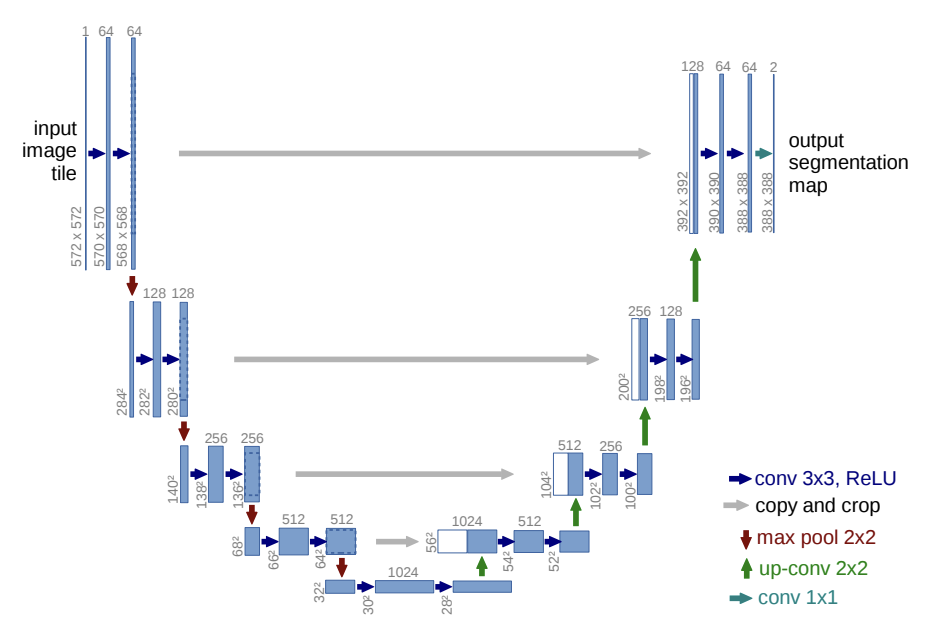

In [ ]:
transfer_unet = smp.Unet(
    encoder_name = 'resnet34',
    encoder_weights = 'imagenet',
    in_channels = 3,
    classes = 1,
    activation = None
).to(DEVICE)

## 2.1 Loss Function Selection
### For the purpose of semantic segmentation, a combination of Binary Cross Entropy with Logits and Dice Loss can be used

In [ ]:
# Dice Loss
def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    dice = (2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return 1 - dice

# Binary Cross Entropy with Logits
bce_loss = nn.BCEWithLogitsLoss()

# Combined Loss
def combined_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)

## 2.2 Evaluation Metrics
### For the purpose of evaluation, we can use the Intersection over Union (IoU) and Dice Coefficient as evaluation metrics to measure the quality/accuracy of the segmentation map

In [ ]:
# Intersection over Union Metric
def iou_score(pred, target, threshold = 0.5, smooth = 1e-6):
    pred = torch.sigmoid(pred) > threshold
    target = target > 0.5

    intersection = (pred & target).float().sum((1,2,3))
    union = (pred | target).float().sum((1,2,3))

    return ((intersection + smooth) / (union + smooth)).mean().item()

# Dice Coefficient Metric
def dice_score(pred, target, threshold = 0.5, smooth = 1e-6):
    pred = torch.sigmoid(pred) > threshold
    target = target > 0.5

    intersection = (pred & target).float().sum((1,2,3))
    dice = (2 * intersection + smooth) / (
        pred.float().sum((1,2,3)) + 
        target.float().sum((1,2,3)) + smooth)

    return dice.mean().item()

# 3. Training Setup
## 3.0 Details 
### - Optimizer: Adam
### - Fixed Resolution Input
### - Validation metrics on the entire validation set
### - Best model checkpoint selection for highest validation IoU score

In [ ]:
# Loading data in the dataloader
BATCH_SIZE = 8
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset, 
    batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    shuffle = True,
    pin_memory = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

## 3.1 Training Function for one epoch

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss/len(loader.dataset)
    return epoch_loss

## 3.2 Validation Function for one epoch

In [ ]:
@torch.no_grad()
def val_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    iou_scores = []
    dice_scores = []
    
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        running_loss += loss.item() * images.size(0)

        iou_scores.append(iou_score(outputs, masks))
        dice_scores.append(dice_score(outputs, masks))

    epoch_loss = running_loss/len(loader.dataset)
    mean_iou = sum(iou_scores)/len(iou_scores)
    mean_dice = sum(dice_scores)/len(dice_scores)

    return epoch_loss, mean_iou, mean_dice

## 3.3 Training and Validation Loop

## 3.4 Plotting Losses and Evaluation Metrics

## 3.5 Loading parameters of model with the best IoU Score on Val Dataset

## 3.6 Visualizing model performance on a few samples

In [ ]:
@torch.no_grad()
def visualize_prediction(dataset, idx, model, device):
    image, mask = dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)
    pred = model(input_tensor)

    pred_mask = (torch.sigmoid(pred) > 0.5).float()

    # Denormalize image for visualization
    image_np = denormalize(image)

    gt_mask = mask.squeeze().cpu().numpy()
    pred_mask = pred_mask.squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize = (15, 5))

    axes[0].imshow(image_np)
    axes[0].set_title('Image')
    axes[0].axis('off')

    axes[1].imshow(gt_mask, cmap = 'gray')
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    axes[2].imshow(pred_mask, alpha = 0.9, cmap = 'jet')
    axes[2].set_title('prediction mask')
    axes[2].axis('off')

    axes[3].imshow(image_np)
    axes[3].imshow(pred_mask, alpha = 0.6, cmap = 'jet')
    axes[3].set_title('prediction on image')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):

    if tensor.ndim == 4:
        tensor = tensor[0]

    mean = IMAGENET_MEAN[:, None, None]
    std = IMAGENET_STD[:, None, None]

    tensor = tensor.cpu() * std + mean
    tensor = tensor.clamp(0, 1)

    return tensor.permute(1, 2, 0).numpy()

## 3.7 Failure Case Visualizations
### Visualizing worst segmemtation performance on samples

In [ ]:
@torch.no_grad()
def compute_per_sample_iou(model, dataset, device):
    model.eval()
    scores = []

    for idx in range(len(dataset)):
        image, mask = dataset[idx]

        image = image.unsqueeze(0).to(device)
        mask  = mask.unsqueeze(0).to(device) 

        pred = model(image)
        iou = iou_score(pred, mask)

        scores.append((idx, iou))

    return scores

# 4. Implementing Transfer Learning for better segmentation
## 4.0 Setup
### I will be using a ResNET 34 trained on the ImageNET dataset as the encoder for transfer learning on the UNet.

## 4.1 Training Regime
### Warm Up: Initially, the encoder weights will be frozen for a few epochs so the decoder can learn from the extracted encoder features. 
### Fine-tuning: Finally, during fine-tuning, the encoder weights will be unfrozen and the learning rate will be set at a low value.

## 4.2 Warm Up Phase

In [ ]:
# Freezing the weights in the encoder for the warm up phase
for param in transfer_unet.encoder.parameters():
    param.requires_grad = False

# Optimizer
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, transfer_unet.parameters()), lr = 1e-3)

# Loss function
criterion = combined_loss

print('Warm up phase for a few epochs with frozen encoder\n')
WARMUP_EPOCHS = 5

best_val_iou = 0.0
tl_history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_dice': []
}

for epoch in range(WARMUP_EPOCHS):
    train_loss = train_one_epoch(
        transfer_unet,
        train_loader,
        optimizer,
        combined_loss,
        DEVICE
    )

    val_loss, val_iou, val_dice = val_one_epoch(
        transfer_unet,
        val_loader,
        combined_loss,
        DEVICE
    )

    tl_history['train_loss'].append(train_loss)
    tl_history['val_loss'].append(val_loss)
    tl_history['val_iou'].append(val_iou)
    tl_history['val_dice'].append(val_dice)

    print(
        f"Epoch [{epoch + 1}/{WARMUP_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"IoU: {val_iou:.4f} | "
        f"Dice: {val_dice:.4f}"
    )

## 4.3 Fine-tuning Phase

In [ ]:
# Unfreezing the encoder weights
for param in transfer_unet.encoder.parameters():
    param.requires_grad = True

# Optimizer with lowered learning rate
optimizer = torch.optim.Adam(transfer_unet.parameters(), lr = 1e-4)

# Loss function
criterion = combined_loss

print('Fine-tune phase for a few epochs with unfrozen encoder\n')
FINETUNE_EPOCHS = 10

best_val_iou = 0.0

for epoch in range(FINETUNE_EPOCHS):
    train_loss = train_one_epoch(
        transfer_unet,
        train_loader,
        optimizer,
        combined_loss,
        DEVICE
    )

    val_loss, val_iou, val_dice = val_one_epoch(
        transfer_unet,
        val_loader,
        combined_loss,
        DEVICE
    )

    tl_history['train_loss'].append(train_loss)
    tl_history['val_loss'].append(val_loss)
    tl_history['val_iou'].append(val_iou)
    tl_history['val_dice'].append(val_dice)

    print(
        f"Epoch [{epoch + 1}/{FINETUNE_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"IoU: {val_iou:.4f} | "
        f"Dice: {val_dice:.4f}"
    )

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(transfer_unet.state_dict(), "best_transfer_unet.pth")
        print('Best model saved')

## 4.4 Plotting the Performance of the Transfer Learning UNet

In [ ]:
epochs = range(WARMUP_EPOCHS + FINETUNE_EPOCHS)

plt.figure(figsize = (14, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, tl_history['train_loss'], label = 'Train Loss')
plt.plot(epochs, tl_history['val_loss'], label = 'Val Loss')
plt.xticks(np.arange(0,WARMUP_EPOCHS + FINETUNE_EPOCHS), np.arange(1, WARMUP_EPOCHS + FINETUNE_EPOCHS + 1))
plt.xlabel('(Epochs)')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.axvspan(0,WARMUP_EPOCHS, ymin = 0,  
            ymax = 1, 
            color ='yellow', 
            alpha = 0.4) 
plt.axvspan(WARMUP_EPOCHS, WARMUP_EPOCHS + FINETUNE_EPOCHS - 1, ymin = 0,  
            ymax = 1, 
            color ='green', 
            alpha = 0.4) 

plt.subplot(1, 3, 2)
plt.plot(epochs, tl_history['val_iou'])
plt.xticks(np.arange(0,WARMUP_EPOCHS + FINETUNE_EPOCHS), np.arange(1, WARMUP_EPOCHS + FINETUNE_EPOCHS + 1))
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('Validation IoU')
plt.axvspan(0,WARMUP_EPOCHS, ymin = 0,  
            ymax = 1, 
            color ='yellow', 
            alpha = 0.4) 
plt.axvspan(WARMUP_EPOCHS, WARMUP_EPOCHS + FINETUNE_EPOCHS - 1, ymin = 0,  
            ymax = 1, 
            color ='green', 
            alpha = 0.4) 

plt.subplot(1, 3, 3)
plt.plot(epochs, tl_history['val_dice'])
plt.xticks(np.arange(0,WARMUP_EPOCHS + FINETUNE_EPOCHS), np.arange(1, WARMUP_EPOCHS + FINETUNE_EPOCHS + 1))
plt.xlabel('Epochs')
plt.ylabel('Dice')
plt.title('Validation Dice')
plt.axvspan(0,WARMUP_EPOCHS, ymin = 0,  
            ymax = 1, 
            color ='yellow', 
            alpha = 0.4) 
plt.axvspan(WARMUP_EPOCHS, WARMUP_EPOCHS + FINETUNE_EPOCHS - 1, ymin = 0,  
            ymax = 1, 
            color ='green', 
            alpha = 0.4) 

plt.suptitle('Transfer Learning Model')
plt.tight_layout()
plt.show()

## 4.5 Loading the best performing parameters onto the UNet 

In [ ]:
transfer_unet.load_state_dict(torch.load("best_transfer_unet.pth"))
transfer_unet.eval()

## 4.6 Visualizing Segmentation Performance of the model

In [ ]:
for idx in np.random.choice(len(val_dataset), 3, replace = False):
    visualize_prediction(val_dataset, idx, transfer_unet, DEVICE)

## 4.7 Failure Case Visualizations

In [ ]:
tl_val_ious = compute_per_sample_iou(transfer_unet, val_dataset, DEVICE)
tl_val_ious = sorted(tl_val_ious, key=lambda x: x[1])

tl_worst_cases = tl_val_ious[:5]

for idx, score in tl_worst_cases:
    print(f"IoU: {score:.3f}")
    visualize_prediction(val_dataset, idx, transfer_unet, DEVICE)